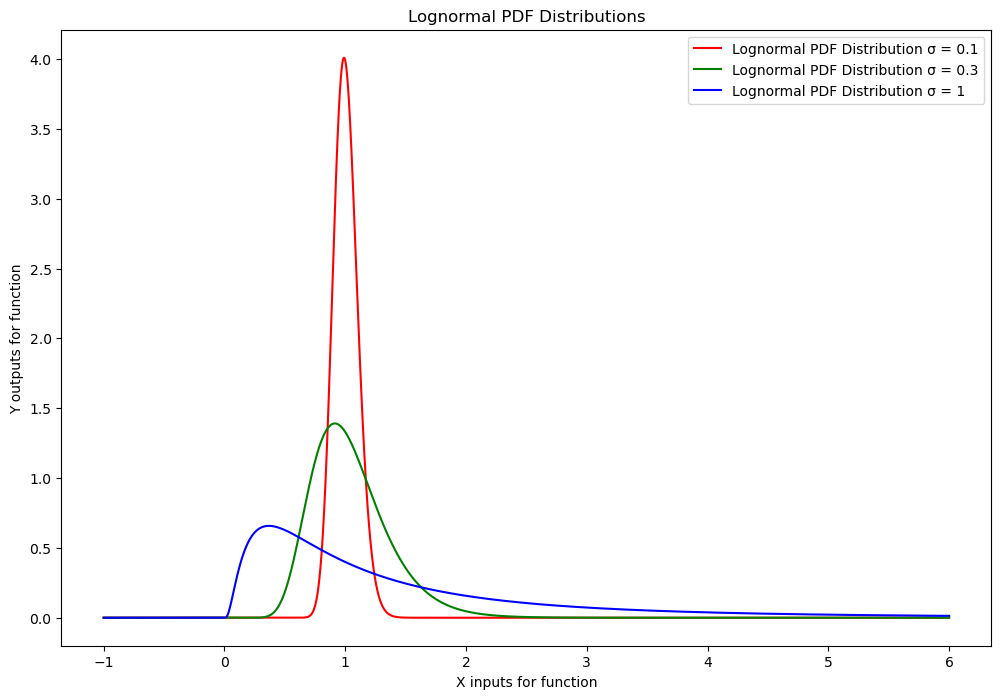

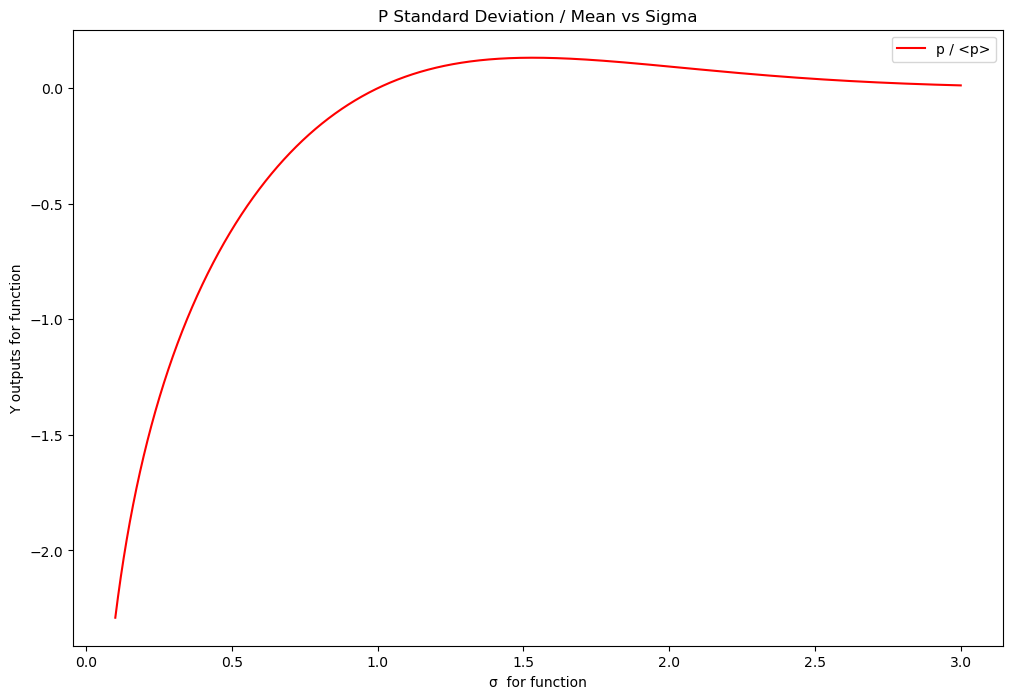

In [12]:
# Problem 1
import numpy as np
from scipy.stats import lognorm
from scipy.integrate import quad 
import scipy.special as special 
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize = (12,8))
s1 = 0.1
s2 = 0.3
s3 = 1
x = np.linspace(-1,6, 10000)
ax.plot(x, lognorm.pdf(x, s1),'r-', label='Lognormal PDF Distribution σ = 0.1')
ax.plot(x, lognorm.pdf(x, s2),'g-', label='Lognormal PDF Distribution σ = 0.3')
ax.plot(x, lognorm.pdf(x, s3),'b-', label='Lognormal PDF Distribution σ = 1')
ax.set_title('Lognormal PDF Distributions')
ax.set_xlabel('X inputs for function')
ax.set_ylabel('Y outputs for function')
ax.legend()

# Part D

# Let ρ± be values of ρ that serve as analogs of ±σ for a Gaussian distribution:
# P(< ρ−) = 0.16
# P(> ρ+) = 0.16
# Plot ρ±/⟨ρ⟩ vs σ for 0.1 ≤ σ ≤ 3

# Expectation value 
fig, ax = plt.subplots(1, 1, figsize = (12,8))
σ = np.linspace(0.1, 3, 10000)
p = np.log(σ)
# For mu = 0
exp_p = np.exp((σ ** 2) / 2)
ax.plot(σ, p /exp_p ,'r-', label = 'p / <p>')
ax.set_title('P Standard Deviation / Mean vs Sigma')
ax.set_xlabel('σ  for function')
ax.set_ylabel('Y outputs for function')
ax.legend()

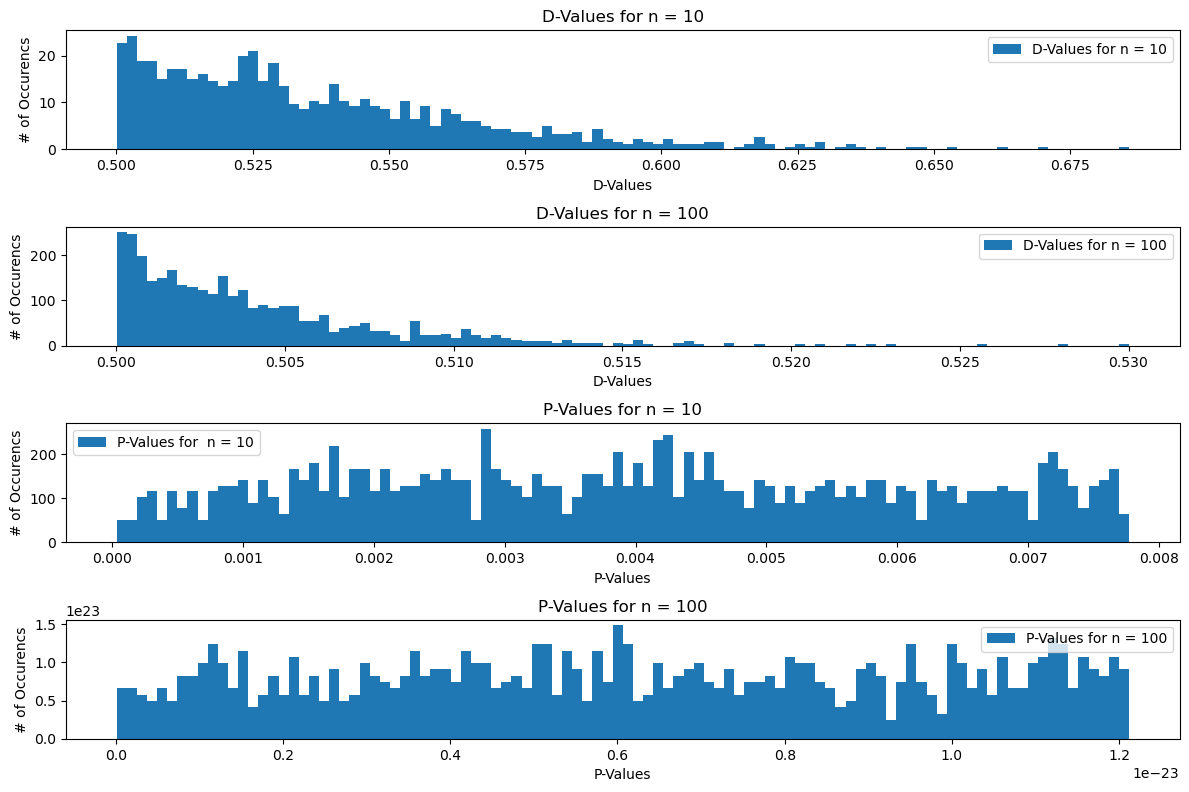

In [57]:
# Problem 2
# Write a function that:
# 1. generates a sample of n uniformly distributed random variables;
# 2. performs a KS test of your sample and the exact CDF of the uniform distribution using
# scipy.stats.kstest.
# 3. returns the value of the KS statistic D and its associated p-value.
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats


def num_gen(n):
    lst = np.random.uniform(size = n) 
    x = stats.kstest(lst,stats.norm.cdf)
    D = x[0]
    p = x[1]
    return D,p

# (B) Run your function a large number of times N and plot histograms of D and p for n = 10
# and n = 100. Choose the number of bins for your histograms and the value of N so that
# your histograms are informative (i.e. show the main features of the distribution
def lsts(N,n):
    d_lst = []
    p_lst = []
    for x in range(0,N):
        d,p = num_gen(n)
        d_lst.append(d)
        p_lst.append(p)
    return d_lst, p_lst

D_lst10, P_lst10 = lsts(1000,10)
D_lst100, P_lst100 = lsts(1000,100)

N_points = 10000
n_bins = 100
fig, ax = plt.subplots(4,1,figsize = (12,8))
ax[0].hist(D_lst10, bins = n_bins, alpha = 1, density = True, label = 'D-Values for n = 10')
ax[0].legend()
ax[0].set_title('D-Values for n = 10')
ax[0].set_xlabel('D-Values')
ax[0].set_ylabel('# of Occurencs')

ax[1].hist(D_lst100, bins = n_bins, alpha = 1, density = True, label = 'D-Values for n = 100')
ax[1].legend()
ax[1].set_title('D-Values for n = 100')
ax[1].set_xlabel('D-Values')
ax[1].set_ylabel('# of Occurencs')


ax[2].hist(P_lst10, bins = n_bins, alpha = 1, density = True, label = 'P-Values for  n = 10')
ax[2].legend()
ax[2].set_title('P-Values for n = 10')
ax[2].set_xlabel('P-Values')
ax[2].set_ylabel('# of Occurencs')


ax[3].hist(P_lst100, bins = n_bins, alpha = 1, density = True, label = 'P-Values for n = 100')
ax[3].legend()
ax[3].set_xlabel('P-Values')
ax[3].set_ylabel('# of Occurencs')
ax[3].set_title('P-Values for n = 100')

fig.tight_layout(pad = 1)